## Dataset Porto Seguro Safe Driver Prediction

In [2]:
import pandas as pd
df_train = pd.read_csv('../Cleaned-Dataset/train.csv')
df_test = pd.read_csv('../Cleaned-Dataset/test.csv')

In [3]:
def dataset_split(df_train, df_test):
    train_samples = int(df_train.shape[0] * 0.8)

    X_train, y_train = df_train[:train_samples].drop(columns=['target']), df_train[:train_samples]['target']
    X_valid, y_valid = df_train[train_samples:].drop(columns=['target']), df_train[train_samples:]['target']

    test = df_test
    return X_train, y_train, X_valid, y_valid, test

In [4]:
# Encoding 

def cat_cols_encode(X_train, y_train, X_valid, y_valid, test):
    # Target encode only high-cardinality column
    cat_cols_target = ["ps_car_11_cat"]

    cat_cols_final = [col for col in X_train.columns if col.endswith("_cat")]
    cat_cols_onehot = [col for col in cat_cols_final if col not in cat_cols_target]

    from category_encoders import TargetEncoder, OneHotEncoder
    # --- Target Encoding ---
    target_encoder = TargetEncoder(cols=cat_cols_target, smoothing=0.3)

    X_train = target_encoder.fit_transform(X_train, y_train)
    X_valid = target_encoder.transform(X_valid)
    test = target_encoder.transform(test)

    # --- One Hot Encoding ---
    onehot_encoder = OneHotEncoder(cols=cat_cols_onehot, use_cat_names=True)

    X_train = onehot_encoder.fit_transform(X_train)
    X_valid = onehot_encoder.transform(X_valid)
    test = onehot_encoder.transform(test)

    return X_train, y_train, X_valid, y_valid, test

In [5]:
X_train, y_train, X_valid, y_valid, test = dataset_split(df_train, df_test)
X_train, y_train, X_valid, y_valid, test = cat_cols_encode(X_train, y_train, X_valid, y_valid, test)

- optimal for decision Tree
    - max_depth = 6,
    - min_samples_split = 10,
    - min_samples_leaf = 3,
    - max_features = 60,
    - max_leaf_nodes = 300,
    - min_impurity_decrease = 2e-5,
    - min_cost_complexity = 0.0,
    - pos_weight=5,

## Random Forest Sklearn

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

rf_sklearn = RandomForestClassifier(
    n_estimators=500,           # more trees = smoother
    max_depth=7,                # prevent overfitting
    min_samples_split=500,
    min_samples_leaf=100,
    max_features=0.2,        # critical for decorrelation on redundant features
    bootstrap=True,
    oob_score=True,             # we will compare with our OOB
    n_jobs=-1,
    random_state=42,
    criterion='gini',
    class_weight= {0:1, 1:25}  # 'balanced'     # handles mild imbalance
)

rf_sklearn.fit(X_train, y_train)
print("Sklearn OOB score:", rf_sklearn.oob_score_)
# 4 mins

from sklearn.metrics import roc_auc_score

y_preds_sklearn = rf_sklearn.predict_proba(X_valid)[:, 1]
print("valid AUC Score:", roc_auc_score(y_valid, y_preds_sklearn))
print("Top 5 features (should down-weight redundant & noise):", 
      np.argsort(rf_sklearn.feature_importances_)[-5:])

Sklearn OOB score: 0.6985335038610241
valid AUC Score: 0.6251989176388686
Top 5 features (should down-weight redundant & noise): [ 9 30 26 83 86]


## Models From Scratch 

### Decision Tree From Scratch

In [6]:
import numpy as np
import pandas as pd

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, class_label=None, proba=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.class_label = class_label
        self.proba = proba

class DecisionTreeFromScratch_Opt_Time:
    def __init__(self, max_depth=10, min_samples_leaf=10, min_samples_split=20, 
                 max_features=None, pos_weight=5.0, max_leaf_nodes=None, 
                 min_impurity_decrease=0.0, min_cost_complexity=1e-6, 
                 leaf_smoothing=15.0, random_state=42):
        # Pre-Pruning
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split  = min_samples_split
        self.max_leaf_nodes = max_leaf_nodes   # Global leaf counter and stops splitting when limit reached
        self.min_impurity_decrease = min_impurity_decrease
        self.max_features = max_features  # Can be None, int, float, 'sqrt', 'log2'
        self.leaf_smoothing = leaf_smoothing
        
        # Post-Pruning
        self.ccp_alpha = min_cost_complexity # ccp_alpha Simple postpruning stub that removes subtrees 
                                    # whose impurity improvement is less than alpha

        # Extra Pruning for this Dataset
        self.pos_weight = pos_weight # Imbalance Handling
        
        self.random_state = random_state  
        np.random.seed(random_state)

        self.root = None
        self.leaf_count = 0
        self.n_features_ = None
    
    def _best_split(self, X, y, indices):
        """Highly vectorized best split using cumulative sums."""
        m = len(indices)

        if m < self.min_samples_split:
            return None, None

        best_gini = float('inf')
        best_feature, best_threshold = None, None

        parent_gini = 0.0  # Will compute later

        n_features = X.shape[1]
        k = 1
        # max_features regularization 
        if self.max_features is None:
            # features = np.arange(n_features)
            k = n_features
        else: 
            if isinstance(self.max_features, str):
                if self.max_features == 'sqrt':
                    k = max(1, int(np.sqrt(n_features)))
                elif self.max_features == 'log2':
                    k = max(1, int(np.log2(n_features)))
                else:
                    k = n_features
            elif isinstance(self.max_features, float) and 0 < self.max_features < 1:
                k = max(1, int(self.max_features * n_features))
            else:
                k = max(1, int(self.max_features))  
        
        k = min(k, n_features)
        feature_list = np.random.choice(n_features, k, replace=False)

        # Parent gini ( for min_impurity_decrease)
        y_subset = y[indices]
        pos = np.sum(y_subset == 1).astype(np.float64)
        neg = m - pos

        pos *= self.pos_weight
        total_w = pos + neg
        p = pos / total_w if total_w > 0 else 0.5

        parent_gini = 1 - (p**2 + (1-p)**2)


        for feat_idx in feature_list:
            # Sort indices by current features
            sorted_idx = indices[np.argsort(X[indices, feat_idx])]
            X_sorted = X[sorted_idx, feat_idx]
            y_sorted = y[sorted_idx]

            # Convert labels to 0/1 (important for speed)
            y_bin = (y_sorted == 1).astype(np.float64)

            # Total counts
            total_pos = y_bin.sum()
            total_neg = m - total_pos

            # Cumulative sums → vectorized left counts
            left_pos = np.cumsum(y_bin)[:-1]
            left_neg = np.cumsum(1 - y_bin)[:-1]

            # Right counts
            right_pos = total_pos - left_pos
            right_neg = total_neg - left_neg

            # Valid splits mask
            split_points = np.arange(1, m)
            valid = (
                (split_points >= self.min_samples_leaf) &
                ((m - split_points) >= self.min_samples_leaf) &
                (X_sorted[1:] != X_sorted[:-1])
            )

            if not np.any(valid):
                continue
            
            # Use class weights to find gini
            left_pos *= self.pos_weight
            right_pos *= self.pos_weight

            # Gini computation (vectorized)
            left_total = left_pos + left_neg
            right_total = right_pos + right_neg

            # Avoid division by zero
            left_total = np.maximum(left_total, 1e-8)
            right_total = np.maximum(right_total, 1e-8)

            p_left_pos = left_pos / left_total
            p_left_neg = left_neg / left_total

            p_right_pos = right_pos / right_total
            p_right_neg = right_neg / right_total

            gini_left = 1 - (p_left_pos**2 + p_left_neg**2)
            gini_right = 1 - (p_right_pos**2 + p_right_neg**2)

            # Weighted gini
            weights_left = left_total / (left_total + right_total)
            weights_right = right_total / (left_total + right_total)

            weighted_gini = weights_left * gini_left + weights_right * gini_right

            # Apply valid mask
            weighted_gini[~valid] = np.inf

            # min_impurity_decrease regularization
            impurity_decrease = parent_gini - weighted_gini

            weighted_gini[impurity_decrease < self.min_impurity_decrease] = np.inf

            # Find best split for this feature
            idx = np.argmin(weighted_gini)
            gini = weighted_gini[idx]

            if gini < best_gini:
                best_gini = gini
                best_feature = feat_idx
                best_threshold = (X_sorted[idx] + X_sorted[idx + 1]) / 2

            # Early stopping for already optimized gain
            if best_gini < 1e-6:
                break

        return best_feature, best_threshold

    
    # Recursive tree building (No Array Copying)
    def _build_tree(self, X, y, indices, depth=0):
        """Recursive tree building."""
        m = len(indices)
        if m==0:
            return Node(class_label=0, proba=0.5)
        
        y_subset = y[indices]

        pos = np.sum(y_subset == 1)
        # Smoothed probability
        proba = (pos + self.leaf_smoothing) / (m + 2 * self.leaf_smoothing)

        # max_leaf_nodes regularization
        if self.max_leaf_nodes is not None:
            self.leaf_count += 1
            if self.leaf_count > self.max_leaf_nodes:
                # Force leaf even if we could split
                label=1 if proba >= (1.0 / self.pos_weight) else 0
                return Node(class_label=label, proba = proba)

        # stopping condition.
        if (depth >= self.max_depth or 
            m < self.min_samples_split or 
            len(np.unique(y_subset)) == 1):
            label = 1 if proba >= (1.0 / self.pos_weight) else 0
            return Node(class_label=label, proba=proba)
        
        feature, threshold = self._best_split(X, y, indices)

        if feature is None: 
            label = 1 if proba >= (1.0 / self.pos_weight) else 0
            return Node(class_label=label, proba=proba)
        
        mask = X[indices, feature] <= threshold
        left_indices = indices[mask]
        right_indices = indices[~mask]

        left = self._build_tree(X, y, left_indices, depth + 1)
        right = self._build_tree(X, y, right_indices, depth + 1)
        return Node(feature=feature, threshold=threshold, left=left, right=right)
    

    def _calculate_gini(self, proba):
        p = np.clip(proba, 1e-15, 1 - 1e-15)
        return 1 - (p**2 + (1-p)**2)



    # Fit
    def fit(self, X, y):
        """Fit the model."""
        X = np.array(X, dtype=np.float32)
        y = (np.array(y).ravel() == 1).astype(np.int32)

        self.n_features_ = X.shape[1]
        indices = np.arange(len(y))
        self.leaf_count = 0
        self.root = self._build_tree(X, y, indices)

        # Post-Pruning
        # if self.ccp_alpha > 0:
        #     self.root = self._prune(self.root)
        
        return self

    def _predict_one(self, x, node):
        """Traverse tree for one sample."""
        if node is None:
            return 0
        
        if node.class_label is not None:
            return node.class_label
        
        if node.feature is None or node.threshold is None:
            # Fallback to majority (rare edge case after aggressive pruning)
            return 1 if (node.proba or 0.5) >= (1.0 / self.pos_weight) else 0
        
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
        
    def predict(self, X):
        """Predict the model for a test case."""
        X = np.array(X, dtype=np.float32)
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_proba_one(self, x, node):
        """Traverse tree for one sample to get target probability."""
        if node is None:
            return 0.5

        if node.proba is not None:
            return node.proba
        
        if node.feature is None or node.threshold is None:
            # Fallback to majority (rare edge case after aggressive pruning)
            return float(node.proba) if node.proba is not None else 0.5

        if x[node.feature] <= node.threshold:
            return self._predict_proba_one(x, node.left)
        else:
            return self._predict_proba_one(x, node.right)
        
    def predict_proba(self, X):
        """Predict the probability of target with model for a test case."""
        X = np.array(X, dtype=np.float32)
        proba = np.array([self._predict_proba_one(x, self.root) for x in X])
        proba = np.nan_to_num(proba, nan=0.5)
        return proba

### Random Forest From Scratch

In [7]:
from sklearn.metrics import roc_auc_score
from scipy.stats import mode

class RandomForestClassifierScratch:

    def __init__(
        self,
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=30,
        min_samples_split=50,
        max_leaf_nodes=200,
        max_features=None,
        min_cost_complexity=1e-4,
        bootstrap=True,
        oob_score=False,
        min_impurity_decrease=1e-4,
        # reg_gamma=1e-3,
        # reg_lambda=1e-4,
        leaf_smoothing=15.0,
        pos_weight=5,
        random_state=None
    ):

        self.n_estimators = n_estimators

        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.max_leaf_nodes = max_leaf_nodes   # Global leaf counter and stops splitting when limit reached
        self.max_features = max_features
        self.ccp_alpha = min_cost_complexity
        self.pos_weight = pos_weight
        self.leaf_smoothing = leaf_smoothing

        self.bootstrap = bootstrap
        self.oob_score = oob_score
        self.random_state = random_state
        self.min_impurity_decrease=min_impurity_decrease
        # self.reg_lambda=reg_lambda
        # self.reg_gamma=reg_gamma
        
        self.random_state = random_state 
        # np.random.seed(random_state)

        self.trees = []
        self.oob_score_ = None

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y).ravel()

        n_samples = X.shape[0]

        rng = np.random.RandomState(self.random_state)

        self.trees = []

       #  oob_predictions = [[] for _ in range(n_samples)]        # No of samples x No of predictions

        # ====================================== TRAIN DECISION TREES =========================== #
        for i in range(self.n_estimators):

            # ============================== BOOTSTRAP SAMPLING ================================= #
            if self.bootstrap:
                # Seperate Pos and negative indices
                pos_idx = np.where(y == 1)[0]
                neg_idx = np.where(y == 0)[0]

                # Undersample majority 
                n_pos = len(pos_idx)
                n_neg = int(self.pos_weight * n_pos)
                n_total = (n_neg + n_pos)

                sample_pos = rng.choice(pos_idx, size=int(n_pos * 0.7), replace=True)
                sample_neg = rng.choice(neg_idx, size=int(n_neg * 0.7), replace=True)
                sample_idx = np.concatenate([sample_pos, sample_neg])

                # sample_idx = rng.choice(n_samples, size=req_samples, replace=True)

                in_bag = np.zeros(n_samples, dtype=bool)
                in_bag[sample_idx] = True

                oob_idx = np.where(~in_bag)[0]
            else:
                sample_idx = np.arange(n_samples)
                oob_idx = np.array([], dtype=int)

            tree = DecisionTreeFromScratch_Opt_Time(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                min_cost_complexity=self.ccp_alpha,
                max_features=self.max_features,
                max_leaf_nodes=self.max_leaf_nodes,
                pos_weight = self.pos_weight,
                leaf_smoothing = self.leaf_smoothing,
                min_impurity_decrease=self.min_impurity_decrease
            )
                # reg_lambda=self.reg_lambda,
                # reg_gamma=self.reg_gamma

            tree.fit(X[sample_idx], y[sample_idx])

            self.trees.append(tree)

            # ========================= PREDICT OOB SAMPLE ==================================== #
            if self.oob_score:
                oob_probs = [[] for _ in range(n_samples)]

                if self.bootstrap and len(oob_idx) > 0:
                    oob_pred_proba = tree.predict_proba(X[oob_idx])

                    if (i+1) % 20 == 0:
                        print(f"Trained {i+1}/{self.n_estimators} tree. OOB Prediction: {roc_auc_score(y[oob_idx], oob_pred_proba)}")
                
                    for j, idx in enumerate(oob_idx):
                        oob_probs[idx].append(oob_pred_proba[j])

        # ======================= COMPUTE OOB SCORE ==================================== #
        if self.oob_score:
            oob_final_proba = np.full(n_samples, 0.5, dtype=np.float32)
            for i in range(n_samples):
                if len(oob_probs[i]) > 0:
                    oob_final_proba[i] = np.mean(oob_probs[i])

            valid = np.array([len(oob_probs[i]) > 0 for i in range(n_samples)])
            if valid.any():
                self.oob_score_ = roc_auc_score(y[valid], oob_final_proba[valid])
                print(f"OOB AUC : {self.oob_score_:.5f}")

        return self

    # ----------------------------
    # Predict
    # ----------------------------
    def predict(self, X):

        X = np.array(X)

        tree_preds = np.array([tree.predict(X) for tree in self.trees])

        return mode(tree_preds, axis=0, keepdims=False).mode.ravel()

    # ----------------------------
    # Predict Probabilities
    # ----------------------------
    def predict_proba(self, X):
        """Average probabilities across all trees with safety."""
        X = np.asarray(X, dtype=np.float32)
        n_samples = X.shape[0]
        
        # Collect probabilities safely
        tree_probas = []
        for tree in self.trees:
            try:
                p = tree.predict_proba(X)  # now guaranteed 1D
                if isinstance(p, (list, tuple)):
                    p = np.array(p, dtype=np.float64)
                p = np.asarray(p).ravel()   # force 1D
                if len(p) != n_samples:
                    p = np.full(n_samples, 0.5, dtype=np.float64)  # fallback
                tree_probas.append(p)
            except Exception:
                tree_probas.append(np.full(n_samples, 0.5, dtype=np.float64))
        
        if not tree_probas:
            return np.full(n_samples, 0.5, dtype=np.float64)
        
        # Stack and mean
        probs_array = np.stack(tree_probas, axis=0)   # (n_trees, n_samples)
        mean_proba = np.mean(probs_array, axis=0)
        return mean_proba


IMP Parameters:
- n_estimators
- max_features
- pos_weight
- max_depth
- min_samples_leaf
- min_samples_split
- bootstrap
- min_impurity_decrease
- oob_score
- leaf_smoothing

### Hyper-parameter Tuning

In [8]:
pos_idx = np.where(y_train == 1)[0] # 
neg_idx = np.where(y_train == 0)[0]
ratio = len(neg_idx)/len(pos_idx)
len(pos_idx), len(neg_idx), ratio


(17341, 458828, 26.459143071333834)

In [ ]:
sample_size = 55000
# Seperate Pos and negative indices


rng = np.random.RandomState(42)
sample_pos = rng.choice(pos_idx, size=2000, replace=True)
sample_neg = rng.choice(neg_idx, size=53000, replace=True)
sample_idx = np.concatenate([sample_pos, sample_neg])

X_train_sub, y_train_sub = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

default_params = {
    'n_estimators': 100,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 6,
    'min_samples_split': 50,
    'min_samples_leaf': 20,
    'max_features': 'sqrt',
    'min_impurity_decrease': 0.0,
    'leaf_smoothing': 1.0,
    'pos_weight': 26.5,
    'random_state': 42
}

#### Tune and Plot

In [18]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def tune_and_plot(param_name, param_values, xlabel):
    """Tune one parameter while others default."""
    auc_scores = []
    for val in param_values:
        params = default_params.copy()
        params[param_name] = val
        #try:
        print(f"Started on {param_name}:{val}")
        model_RF = RandomForestClassifierScratch(**params)
        model_RF.fit(X_train_sub, y_train_sub)
        proba_val = model_RF.predict_proba(X_valid)
        auc = roc_auc_score(y_valid, proba_val)
        # Safe printing: handle None specially
        val_str = "None" if val is None else str(val)

        print(f" {param_name}={val_str:10} -> AUC = {auc:.5f}")
        auc_scores.append(auc)
        
        #except Exception as e:
        #    print(f" {param_name}={val} → ERROR: {type(e).__name__} - {e}")
        #    auc_scores.append(np.nan)

    # Prepare x-axis for plotting (convert None to string)
    x_ticks = ["None" if v is None else str(v) for v in param_values]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(param_values)), auc_scores, marker='o', linewidth=2, markersize=8)
    plt.xticks(range(len(param_values)), x_ticks, rotation=45)
    plt.title(f'AUC Score vs {param_name}', fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Validation AUC Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return auc_scores


In [26]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def tune(param_name, param_values):
    """Tune one parameter while others default."""
    auc_scores = []
    for val in param_values:
        params = default_params.copy()
        params[param_name] = val
        #try:
        print(f"Started on {param_name}:{val}")
        model_RF = RandomForestClassifierScratch(**params)
        model_RF.fit(X_train_sub, y_train_sub)
        proba_val = model_RF.predict_proba(X_valid)
        auc = roc_auc_score(y_valid, proba_val)
        # Safe printing: handle None specially
        val_str = "None" if val is None else str(val)

        print(f" {param_name}={val_str:10} -> AUC = {auc:.5f}")
        auc_scores.append(auc)
        
        #except Exception as e:
        #    print(f" {param_name}={val} → ERROR: {type(e).__name__} - {e}")
        #    auc_scores.append(np.nan)


    return auc_scores

def plot(param_name, param_values, auc_scores, xlabel):
        # Prepare x-axis for plotting (convert None to string)
    x_ticks = ["None" if v is None else str(v) for v in param_values]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(param_values)), auc_scores, marker='o', linewidth=2, markersize=8)
    plt.xticks(range(len(param_values)), x_ticks, rotation=45)
    plt.title(f'AUC Score vs {param_name}', fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Validation AUC Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [25]:
# print("************** Tuning for n_estimators ************************")
# param_values = [50, 100, 150, 200, 250, 300, 350]
# tune_and_plot('n_estimators', param_values, 'no_of_estimators')

************** Tuning for max_features ************************
Started on max_features:7
Trained 20/100 tree. OOB Prediction: 0.5830527156525424
Trained 40/100 tree. OOB Prediction: 0.5844855711732267
Trained 60/100 tree. OOB Prediction: 0.5849070617683946
Trained 80/100 tree. OOB Prediction: 0.5863895372634617
Trained 100/100 tree. OOB Prediction: 0.5824269296358404
OOB AUC : 0.58243
 max_features=7          -> AUC = 0.61164
Started on max_features:10
Trained 20/100 tree. OOB Prediction: 0.5839756566742464
Trained 40/100 tree. OOB Prediction: 0.5818114254745923
Trained 60/100 tree. OOB Prediction: 0.5931717163356293
Trained 80/100 tree. OOB Prediction: 0.5837495389724181
Trained 100/100 tree. OOB Prediction: 0.587534026661925
OOB AUC : 0.58753
 max_features=10         -> AUC = 0.61862
Started on max_features:20
Trained 20/100 tree. OOB Prediction: 0.5936537321133722
Trained 40/100 tree. OOB Prediction: 0.5833228389731054
Trained 60/100 tree. OOB Prediction: 0.5894407857757729
Trained

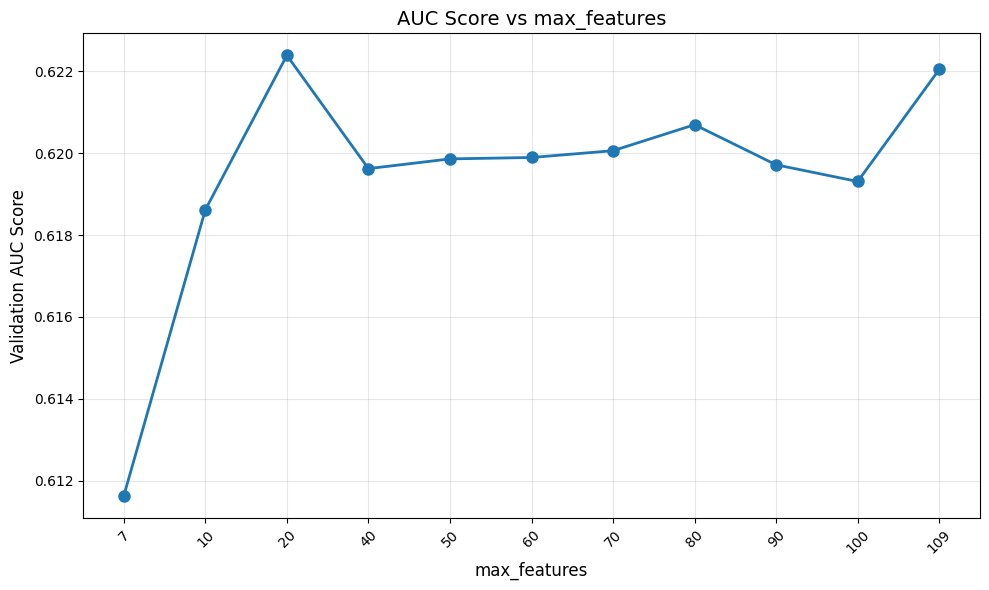

[0.6116357126614063,
 0.6186164596312793,
 0.6223865000945326,
 0.6196221130214536,
 0.6198590324997777,
 0.6198934003560612,
 0.6200594969726021,
 0.6206938701529189,
 0.6197149080361395,
 0.6193078288105791,
 0.6220418310371788]

In [55]:
print("************** Tuning for max_features ************************")
param_values = [7, 10, 20, 40, 50, 60, 70, 80, 90, 100, 109] # [7, 10, 20, 40, 50, 60, 70, 80, 90, 100, 109]
tune_and_plot('max_features', param_values, 'max_features')

- 'max_features' : 20

************** Tuning for max_depth ************************
Started on max_depth:3
Trained 20/100 tree. OOB Prediction: 0.5702799948891987
Trained 40/100 tree. OOB Prediction: 0.5574678468726872
Trained 60/100 tree. OOB Prediction: 0.5598322383580339
Trained 80/100 tree. OOB Prediction: 0.5706001749115936
Trained 100/100 tree. OOB Prediction: 0.5772264335339162
OOB AUC : 0.57723
 max_depth=3          -> AUC = 0.58666
Started on max_depth:5
Trained 20/100 tree. OOB Prediction: 0.561389266679003
Trained 40/100 tree. OOB Prediction: 0.5730355648137581
Trained 60/100 tree. OOB Prediction: 0.5707145446580913
Trained 80/100 tree. OOB Prediction: 0.5488221985626831
Trained 100/100 tree. OOB Prediction: 0.559523421962391
OOB AUC : 0.55952
 max_depth=5          -> AUC = 0.60869
Started on max_depth:6
Trained 20/100 tree. OOB Prediction: 0.5753202644794138
Trained 40/100 tree. OOB Prediction: 0.5860208533542471
Trained 60/100 tree. OOB Prediction: 0.5754169311835902
Trained 80/100 tree. OOB Pre

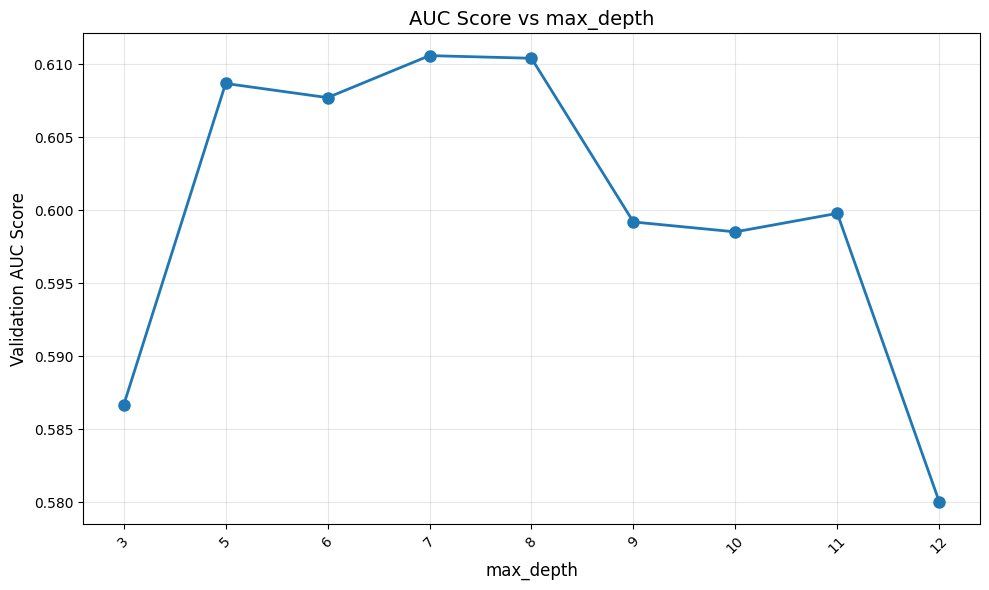

[0.5866643283384568,
 0.60869180071042,
 0.6077237961270242,
 0.610598541715653,
 0.6104189447289438,
 0.5992064336194309,
 0.5985273910392435,
 0.5997963056537488,
 0.580045387283056]

In [20]:
print("************** Tuning for max_depth ************************")
param_values = [3, 5, 6, 7, 8, 9, 10, 11, 12]
tune_and_plot('max_depth', param_values, 'max_depth')

- 'max_depth': [7 try 5 also]

************** Tuning for min_samples_leaf ************************
Started on min_samples_leaf:1
Trained 20/100 tree. OOB Prediction: 0.5755140085182049
Trained 40/100 tree. OOB Prediction: 0.5729738144857525
Trained 60/100 tree. OOB Prediction: 0.5713307825000892
Trained 80/100 tree. OOB Prediction: 0.5633854329061943
Trained 100/100 tree. OOB Prediction: 0.5662557608169052
OOB AUC : 0.56626
 min_samples_leaf=1          -> AUC = 0.61013
Started on min_samples_leaf:2
Trained 20/100 tree. OOB Prediction: 0.5755140085182049
Trained 40/100 tree. OOB Prediction: 0.5729738144857525
Trained 60/100 tree. OOB Prediction: 0.5713727551255949
Trained 80/100 tree. OOB Prediction: 0.5633854329061943
Trained 100/100 tree. OOB Prediction: 0.5662557608169052
OOB AUC : 0.56626
 min_samples_leaf=2          -> AUC = 0.61005
Started on min_samples_leaf:3
Trained 20/100 tree. OOB Prediction: 0.5755140085182049
Trained 40/100 tree. OOB Prediction: 0.5729738144857525
Trained 60/100 tree. OOB Prediction: 0.5

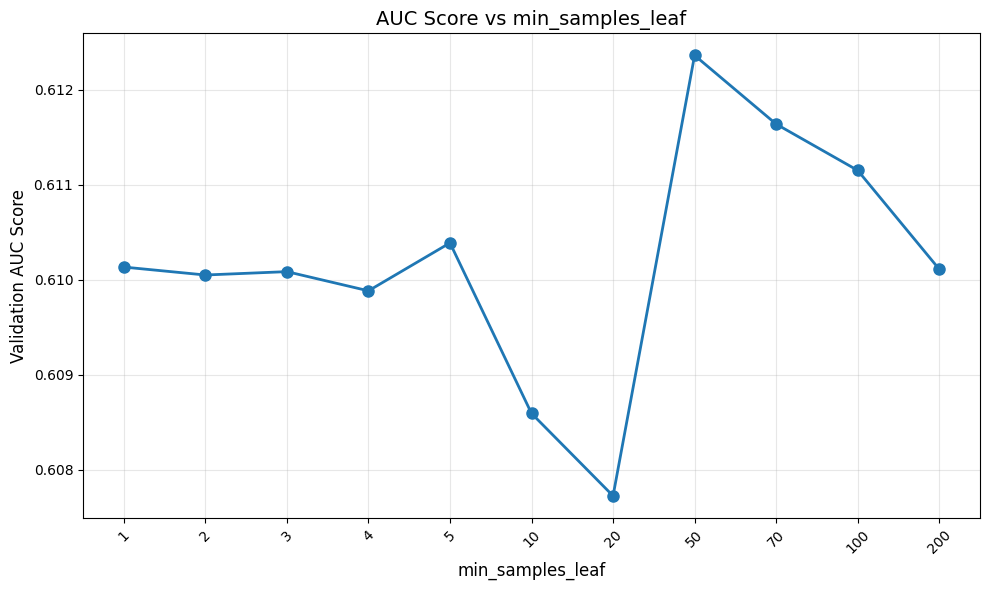

[0.6101344494654204,
 0.6100507872308211,
 0.6100862567493589,
 0.6098841558073315,
 0.6103890175730553,
 0.6085926230652382,
 0.6077237961270242,
 0.6123647667018858,
 0.6116407482594187,
 0.6111530243523242,
 0.6101119174677905]

In [21]:
print("************** Tuning for min_samples_leaf ************************")
param_values = [1, 2, 3, 4, 5, 10, 20, 50, 70, 100, 200]
tune_and_plot('min_samples_leaf', param_values, 'min_samples_leaf')

- 'min_samples_leaf': 50


************** Tuning for min_samples_split ************************
Started on min_samples_split:2
Trained 20/100 tree. OOB Prediction: 0.575772074362464
Trained 40/100 tree. OOB Prediction: 0.5737024491790965
Trained 60/100 tree. OOB Prediction: 0.5757440532387188
Trained 80/100 tree. OOB Prediction: 0.572499410623978
Trained 100/100 tree. OOB Prediction: 0.578733499194496
OOB AUC : 0.57873
 min_samples_split=2          -> AUC = 0.60774
Started on min_samples_split:4
Trained 20/100 tree. OOB Prediction: 0.575772074362464
Trained 40/100 tree. OOB Prediction: 0.5737024491790965
Trained 60/100 tree. OOB Prediction: 0.5757440532387188
Trained 80/100 tree. OOB Prediction: 0.572499410623978
Trained 100/100 tree. OOB Prediction: 0.578733499194496
OOB AUC : 0.57873
 min_samples_split=4          -> AUC = 0.60774
Started on min_samples_split:10
Trained 20/100 tree. OOB Prediction: 0.575772074362464
Trained 40/100 tree. OOB Prediction: 0.5737024491790965
Trained 60/100 tree. OOB Prediction: 0.5

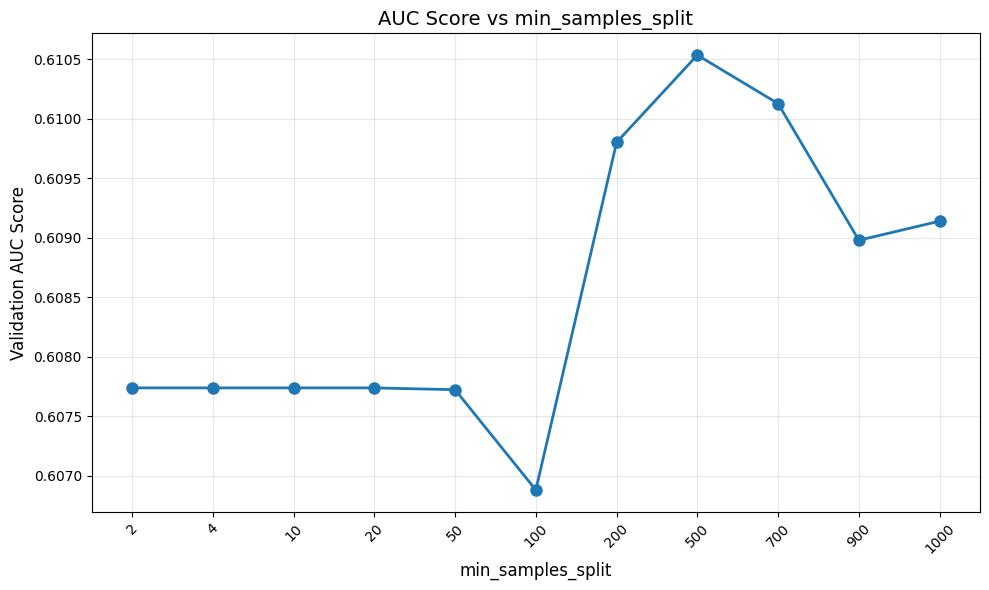

[0.6077389610087076,
 0.6077389610087076,
 0.6077389610087076,
 0.6077389610087076,
 0.6077237961270242,
 0.6068810124844973,
 0.6098025546826584,
 0.6105361015021125,
 0.6101282681386637,
 0.6089797571964435,
 0.609140262376289]

In [22]:
print("************** Tuning for min_samples_split ************************")
param_values = [2, 4, 10, 20, 50, 100, 200, 500, 700, 900, 1000]
tune_and_plot('min_samples_split', param_values, 'min_samples_split')

- 'min_samples_split': 500

************** Tuning for pos_weight ************************
Started on pos_weight:5
Trained 20/100 tree. OOB Prediction: 0.5717819839365711
Trained 40/100 tree. OOB Prediction: 0.563361157010916
Trained 60/100 tree. OOB Prediction: 0.5591060538653856
Trained 80/100 tree. OOB Prediction: 0.5657282281292781
Trained 100/100 tree. OOB Prediction: 0.575700335105361
OOB AUC : 0.57570
 pos_weight=5          -> AUC = 0.60978
Started on pos_weight:10
Trained 20/100 tree. OOB Prediction: 0.5758751526401549
Trained 40/100 tree. OOB Prediction: 0.5555125539854208
Trained 60/100 tree. OOB Prediction: 0.5724951906083673
Trained 80/100 tree. OOB Prediction: 0.5771610948754066
Trained 100/100 tree. OOB Prediction: 0.5839731322619959
OOB AUC : 0.58397
 pos_weight=10         -> AUC = 0.60861
Started on pos_weight:15
Trained 20/100 tree. OOB Prediction: 0.5566912051313428
Trained 40/100 tree. OOB Prediction: 0.5475550428786596
Trained 60/100 tree. OOB Prediction: 0.5689933711044254
Trained 80/100 tree.

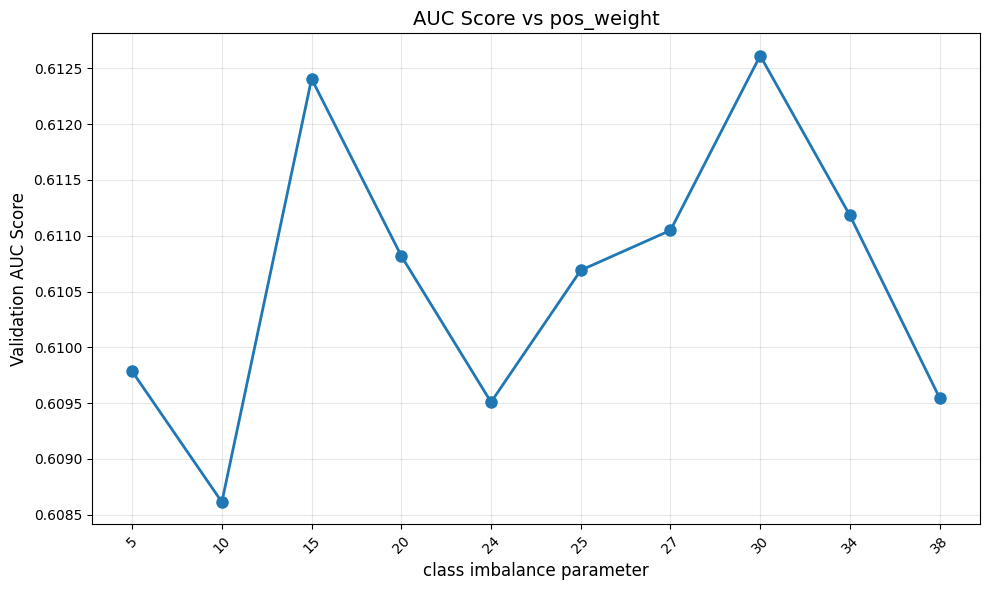

[0.6097847498176099,
 0.6086143558569783,
 0.6124055742748002,
 0.6108183113172141,
 0.6095092320999463,
 0.6106904043234674,
 0.6110480679878642,
 0.6126126587362608,
 0.6111814272082574,
 0.6095468728946358]

In [23]:
print("************** Tuning for pos_weight ************************") # using pos / neg = 0.1 while taking samples
param_values = [5, 10, 15, 20, 24, 25, 27, 30, 34, 38]
tune_and_plot('pos_weight', param_values, 'class imbalance parameter')

- 'pos_weight': 15 or try 30

************** Tuning for min_impurity_decrease ************************
Started on min_impurity_decrease:1e-07
Trained 20/100 tree. OOB Prediction: 0.5753202644794138
Trained 40/100 tree. OOB Prediction: 0.5860208533542471
Trained 60/100 tree. OOB Prediction: 0.5754169311835902
Trained 80/100 tree. OOB Prediction: 0.5662626525723412
Trained 100/100 tree. OOB Prediction: 0.5660680487522771
OOB AUC : 0.56607
 min_impurity_decrease=1e-07      -> AUC = 0.60772
Started on min_impurity_decrease:1e-06
Trained 20/100 tree. OOB Prediction: 0.5753202644794138
Trained 40/100 tree. OOB Prediction: 0.5860208533542471
Trained 60/100 tree. OOB Prediction: 0.5754169311835902
Trained 80/100 tree. OOB Prediction: 0.5662626525723412
Trained 100/100 tree. OOB Prediction: 0.5660680487522771
OOB AUC : 0.56607
 min_impurity_decrease=1e-06      -> AUC = 0.60772
Started on min_impurity_decrease:1e-05
Trained 20/100 tree. OOB Prediction: 0.5753202644794138
Trained 40/100 tree. OOB Prediction: 0.586020853354247

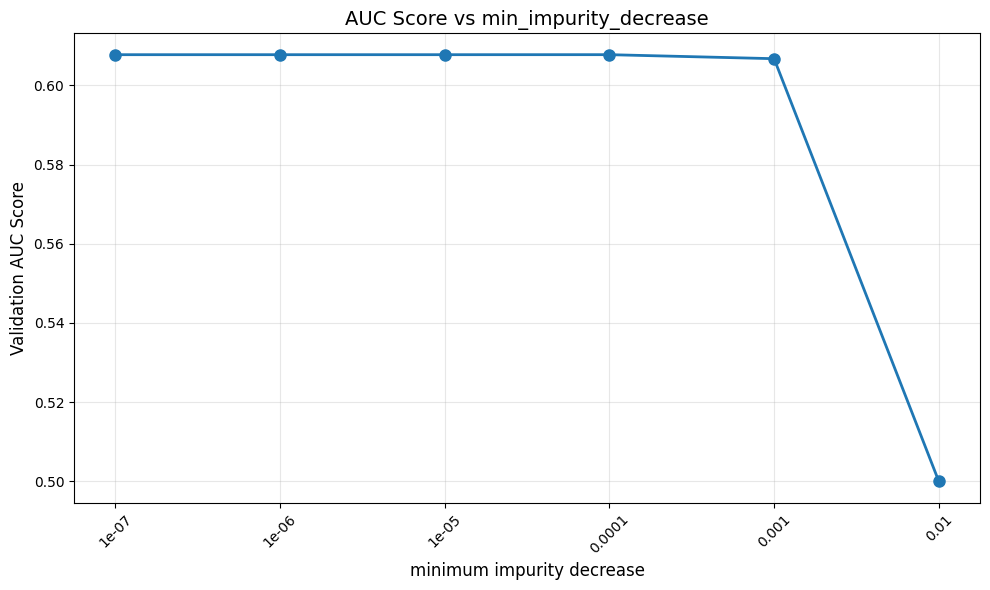

[0.6077237961270242,
 0.6077237961270242,
 0.6077237961270242,
 0.6077291722388243,
 0.6067141026409109,
 0.5]

In [24]:
print("************** Tuning for min_impurity_decrease ************************")
param_values = [1e-7, 1e-6, 1e-5, 1e-4, 0.001, 0.01]
tune_and_plot('min_impurity_decrease', param_values, 'minimum impurity decrease')

- 'min_impurity_decrease': 1e-4

************** Tuning for leaf_smoothing ************************
Started on leaf_smoothing:1
Trained 20/100 tree. OOB Prediction: 0.5753202644794138
Trained 40/100 tree. OOB Prediction: 0.5860208533542471
Trained 60/100 tree. OOB Prediction: 0.5754169311835902
Trained 80/100 tree. OOB Prediction: 0.5662626525723412
Trained 100/100 tree. OOB Prediction: 0.5660680487522771
OOB AUC : 0.56607
 leaf_smoothing=1          -> AUC = 0.60772
Started on leaf_smoothing:2
Trained 20/100 tree. OOB Prediction: 0.5824755193525265
Trained 40/100 tree. OOB Prediction: 0.5854704124645761
Trained 60/100 tree. OOB Prediction: 0.579876196769158
Trained 80/100 tree. OOB Prediction: 0.5653093083387201
Trained 100/100 tree. OOB Prediction: 0.5712721856698239
OOB AUC : 0.57127
 leaf_smoothing=2          -> AUC = 0.60816
Started on leaf_smoothing:4
Trained 20/100 tree. OOB Prediction: 0.5861886745613659
Trained 40/100 tree. OOB Prediction: 0.5870966131057362
Trained 60/100 tree. OOB Prediction: 0.58133160780033

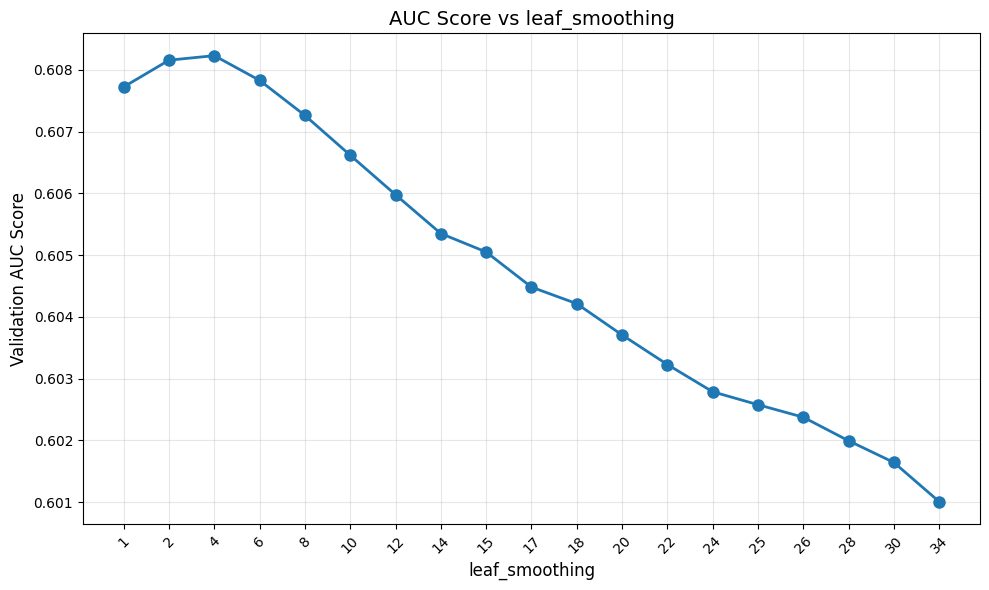

[0.6077237961270242,
 0.6081566332175966,
 0.6082302963649733,
 0.6078298020751592,
 0.6072624079568698,
 0.606617905492882,
 0.6059781942581884,
 0.60534987220818,
 0.605050939160061,
 0.6044824914520524,
 0.6042140864665059,
 0.6037074560321086,
 0.6032285193837574,
 0.6027871434092044,
 0.6025777835144336,
 0.6023752599347051,
 0.6019938644623326,
 0.6016422278919771,
 0.6010072177505752]

In [25]:
print("************** Tuning for leaf_smoothing ************************")
param_values = [1, 2, 4, 6, 8, 10, 12, 14, 15, 17, 18, 20, 22, 24, 25, 26, 28, 30, 34]
tune_and_plot('leaf_smoothing', param_values, 'leaf_smoothing')


- 'leaf_smoothing': 2

### Imp Features Tuning

In [9]:
updated_default_params = {
    'n_estimators': 100,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 6,
    'min_samples_split': 500,
    'min_samples_leaf': 20,
    'max_features': 'sqrt',
    'min_impurity_decrease': 1e-4,
    'leaf_smoothing': 4.0,
    'pos_weight': 26.5,
    'random_state': 42
}

In [10]:
from itertools import product

coarse_grid = {
    'pos_weight': [15, 30],
    'max_features': [20, None],
    'max_depth': [5, 7],
    'min_samples_leaf': [30, 50, 80]
}

# Manual grid search with OOB
results = []
for params_combo in product(*coarse_grid.values()):
    param_dict = dict(zip(coarse_grid.keys(), params_combo))
    full_params = updated_default_params.copy()
    full_params.update(param_dict)
    
    model = RandomForestClassifierScratch(**full_params)
    model.fit(X_train_sub, y_train_sub)   # or full if time allows
    
    oob_auc = model.oob_score_ if model.oob_score_ else 0.0
    val_auc = roc_auc_score(y_valid, model.predict_proba(X_valid))
    gini = 2 * val_auc - 1
    
    results.append((param_dict, oob_auc, val_auc, gini))
    print(param_dict, f"OOB: {oob_auc:.4f} | Val AUC: {val_auc:.4f} | Gini: {gini:.4f}")

Trained 20/100 tree. OOB Prediction: 0.570535988998433
Trained 40/100 tree. OOB Prediction: 0.5986632362985042
Trained 60/100 tree. OOB Prediction: 0.5724888053743394
Trained 80/100 tree. OOB Prediction: 0.5736437965800654
Trained 100/100 tree. OOB Prediction: 0.5611851534299463
OOB AUC : 0.56119
{'pos_weight': 15, 'max_features': 20, 'max_depth': 5, 'min_samples_leaf': 30} OOB: 0.5612 | Val AUC: 0.6115 | Gini: 0.2230
Trained 20/100 tree. OOB Prediction: 0.5711960002281786
Trained 40/100 tree. OOB Prediction: 0.5986632362985042
Trained 60/100 tree. OOB Prediction: 0.5720020488060407
Trained 80/100 tree. OOB Prediction: 0.5736437965800654
Trained 100/100 tree. OOB Prediction: 0.5611851534299463
OOB AUC : 0.56119
{'pos_weight': 15, 'max_features': 20, 'max_depth': 5, 'min_samples_leaf': 50} OOB: 0.5612 | Val AUC: 0.6118 | Gini: 0.2236
Trained 20/100 tree. OOB Prediction: 0.5657554510253466
Trained 40/100 tree. OOB Prediction: 0.577539178226868
Trained 60/100 tree. OOB Prediction: 0.57182

In [11]:
sorted(results, key=lambda x: x[3], reverse=True)[:5]

[({'pos_weight': 30,
   'max_features': 20,
   'max_depth': 7,
   'min_samples_leaf': 80},
  0.5824611742019938,
  0.6182271081544098,
  0.2364542163088197),
 ({'pos_weight': 30,
   'max_features': 20,
   'max_depth': 7,
   'min_samples_leaf': 50},
  0.5791866778832565,
  0.6180052413885213,
  0.23601048277704262),
 ({'pos_weight': 30,
   'max_features': None,
   'max_depth': 7,
   'min_samples_leaf': 80},
  0.5619651476901759,
  0.617144546720765,
  0.23428909344153004),
 ({'pos_weight': 30,
   'max_features': 20,
   'max_depth': 7,
   'min_samples_leaf': 30},
  0.5790068643809715,
  0.6169583137212414,
  0.23391662744248287),
 ({'pos_weight': 15,
   'max_features': None,
   'max_depth': 7,
   'min_samples_leaf': 30},
  0.5746048798031325,
  0.6168524579997776,
  0.23370491599955523)]

## Model Train 

### Model - 1

In [27]:
params1 = {
    'n_estimators': 300,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 5,
    'min_samples_split': 500,
    'min_samples_leaf': 50,
    'max_features': 20,
    'min_impurity_decrease': 1e-4,
    'leaf_smoothing': 2.0,
    'pos_weight': 15,
    'random_state': 42
}

model_RF1 = RandomForestClassifierScratch(**params1)

In [28]:
import time
start = time.time()
model_RF1.fit(X_train, y_train)
end = time.time()

Trained 20/300 tree. OOB Prediction: 0.5876575555690025
Trained 40/300 tree. OOB Prediction: 0.5864562715753707
Trained 60/300 tree. OOB Prediction: 0.593040428719526
Trained 80/300 tree. OOB Prediction: 0.5869909394574457
Trained 100/300 tree. OOB Prediction: 0.5931293454620762
Trained 120/300 tree. OOB Prediction: 0.5882325566319623
Trained 140/300 tree. OOB Prediction: 0.5889917687696248
Trained 160/300 tree. OOB Prediction: 0.5859690283818217
Trained 180/300 tree. OOB Prediction: 0.5826405804697297
Trained 200/300 tree. OOB Prediction: 0.5840164409173962
Trained 220/300 tree. OOB Prediction: 0.5876383110970138
Trained 240/300 tree. OOB Prediction: 0.5914123397289623
Trained 260/300 tree. OOB Prediction: 0.5926072912944553
Trained 280/300 tree. OOB Prediction: 0.5878200288134465
Trained 300/300 tree. OOB Prediction: 0.5834629819156056
OOB AUC : 0.58346


In [29]:
print(f"OOB Score of Model 1: {model_RF1.oob_score_:.5f}")
print(f"Model 1 Training time: {(end - start)/60} mins.")

OOB Score of Model 1: 0.58346
Model 1 Training time: 14.79388786951701 mins.


In [31]:
y_preds_RF1 = model_RF1.predict_proba(X_valid)

from sklearn.metrics import roc_auc_score
auc_rf1 = roc_auc_score(y_valid, y_preds_RF1)
gini_rf1 = 2 * auc_rf1 - 1
print(f"For Model 1 -> AUC Score: {auc_rf1:.5f}, Gini: {gini_rf1:.5f}")

For Model 1 -> AUC Score: 0.61788, Gini: 0.23576


### Model - 2

In [24]:
params2 = {
    'n_estimators': 200,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 7,
    'min_samples_split': 400,
    'min_samples_leaf': 80,
    'max_features': 20,
    'min_impurity_decrease': 1e-4,
    'leaf_smoothing': 2.0,
    'pos_weight': 30,
    'random_state': 42
}
model_RF2 = RandomForestClassifierScratch(**params2)

In [25]:
import time
start = time.time()
model_RF2.fit(X_train, y_train)
end = time.time()

Trained 20/200 tree. OOB Prediction: 0.5955279698477018
Trained 40/200 tree. OOB Prediction: 0.5882635658393889
Trained 60/200 tree. OOB Prediction: 0.5894064378242759
Trained 80/200 tree. OOB Prediction: 0.5953091996626036
Trained 100/200 tree. OOB Prediction: 0.6000269695287852
Trained 120/200 tree. OOB Prediction: 0.5899418357266613
Trained 140/200 tree. OOB Prediction: 0.5896795170459523
Trained 160/200 tree. OOB Prediction: 0.5908245620645382
Trained 180/200 tree. OOB Prediction: 0.5868556825981551
Trained 200/200 tree. OOB Prediction: 0.5919968950718787
OOB AUC : 0.59200


In [29]:
print(f"OOB Score of Model 2: {model_RF2.oob_score_:.5f}")
print(f"Model 2 Training time: {(end - start)/60} mins.")

OOB Score of Model 2: 0.59200
Model 2 Training time: -0.0021265665690104168 mins.


In [30]:
y_preds_RF2 = model_RF2.predict_proba(X_valid)

from sklearn.metrics import roc_auc_score
auc_rf2 = roc_auc_score(y_valid, y_preds_RF2)
gini_rf2 = 2 * auc_rf2 - 1
print(f"For Model 2 -> AUC Score: {auc_rf2:.5f}, Gini: {gini_rf2:.5f}")

For Model 2 -> AUC Score: 0.62539, Gini: 0.25078


In [45]:
params_2a = {
    'n_estimators': 300,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 7,
    'min_samples_split': 380,
    'min_samples_leaf': 85,          # ↑ from 70 (stronger regularization)
    'max_features': 25,              # ← sweet spot for 109 features
    'min_impurity_decrease': 5e-5,
    'leaf_smoothing': 2.0,
    'pos_weight': 28,                # ↑ from 26
    'random_state': 42
}

model_RF2a = RandomForestClassifierScratch(**params_2a)
import time
start = time.time()
model_RF2a.fit(X_train, y_train)          # full training data

print(f"Training time: {(time.time()-start)/60:.1f} min")

y_val_proba = model_RF2a.predict_proba(X_valid)
auc = roc_auc_score(y_valid, y_val_proba)
gini = 2 * auc - 1
print(f"Validation AUC: {auc:.5f} | Gini: {gini:.5f}")

Trained 20/300 tree. OOB Prediction: 0.5917252692010676
Trained 40/300 tree. OOB Prediction: 0.5998059597034274
Trained 60/300 tree. OOB Prediction: 0.5942912281190056
Trained 80/300 tree. OOB Prediction: 0.5979834032154343
Trained 100/300 tree. OOB Prediction: 0.5980374094475185
Trained 120/300 tree. OOB Prediction: 0.5981702492905259
Trained 140/300 tree. OOB Prediction: 0.5938062362162823
Trained 160/300 tree. OOB Prediction: 0.5930086671911795
Trained 180/300 tree. OOB Prediction: 0.5906880613989516
Trained 200/300 tree. OOB Prediction: 0.5945215631691352
Trained 220/300 tree. OOB Prediction: 0.594031759728211
Trained 240/300 tree. OOB Prediction: 0.591661773563727
Trained 260/300 tree. OOB Prediction: 0.5945111126694604
Trained 280/300 tree. OOB Prediction: 0.6042372384275926
Trained 300/300 tree. OOB Prediction: 0.6062260758261526
OOB AUC : 0.60623
Training time: 70.2 min
Validation AUC: 0.62473 | Gini: 0.24947


### Model - 3

In [26]:
params3 = {
    'n_estimators': 350,          # increased from 200
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 8,
    'min_samples_split': 350,
    'min_samples_leaf': 70,
    'max_features': 30,           # ← THIS IS THE KEY CHANGE
    'min_impurity_decrease': 5e-5,
    'leaf_smoothing': 2.0,
    'pos_weight': 26,             # fine-tuned from 30
    'random_state': 42
}

model_RF3 = RandomForestClassifierScratch(**params3)

In [27]:
import time
start = time.time()
model_RF3.fit(X_train, y_train)          # full training data

print(f"Training time: {(time.time()-start)/60:.1f} min")
print(f"OOB AUC: {model_RF3.oob_score_:.5f}")

Trained 20/350 tree. OOB Prediction: 0.5898659332399347
Trained 40/350 tree. OOB Prediction: 0.5724046453888062
Trained 60/350 tree. OOB Prediction: 0.5854739399524309
Trained 80/350 tree. OOB Prediction: 0.5916004997614196
Trained 100/350 tree. OOB Prediction: 0.5933783285435401
Trained 120/350 tree. OOB Prediction: 0.5748154295020506
Trained 140/350 tree. OOB Prediction: 0.5743783622336199
Trained 160/350 tree. OOB Prediction: 0.5710737680828225
Trained 180/350 tree. OOB Prediction: 0.5785149866451869
Trained 200/350 tree. OOB Prediction: 0.5954595235370655
Trained 220/350 tree. OOB Prediction: 0.5884316666616684
Trained 240/350 tree. OOB Prediction: 0.5841032472104347
Trained 260/350 tree. OOB Prediction: 0.5816914284632742
Trained 280/350 tree. OOB Prediction: 0.5998601773541317
Trained 300/350 tree. OOB Prediction: 0.5781786930101159
Trained 320/350 tree. OOB Prediction: 0.5938933683802663
Trained 340/350 tree. OOB Prediction: 0.5975961900248716
OOB AUC : 0.58846
Training time: 75

In [28]:
y_val_proba = model_RF3.predict_proba(X_valid)
auc = roc_auc_score(y_valid, y_val_proba)
gini = 2 * auc - 1
print(f"Validation AUC: {auc:.5f} | Gini: {gini:.5f}")

Validation AUC: 0.62324 | Gini: 0.24648


### Using subset of full dataset for tuning

In [33]:
X_train.shape

(476169, 109)

In [35]:
sample_size = 220000
# Seperate Pos and negative indices

rng = np.random.RandomState(42)
sample_pos = rng.choice(pos_idx, size=8000, replace=True)
sample_neg = rng.choice(neg_idx, size=212000, replace=True)
sample_idx = np.concatenate([sample_pos, sample_neg])

X_train_sub, y_train_sub = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

In [37]:
params2z = {
    'n_estimators': 200,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 7,
    'min_samples_split': 400,
    'min_samples_leaf': 80,
    'max_features': 20,
    'min_impurity_decrease': 1e-4,
    'leaf_smoothing': 2.0,
    'pos_weight': 30,
    'random_state': 42
}
model_RF2z = RandomForestClassifierScratch(**params2z)
import time
start = time.time()
model_RF2z.fit(X_train_sub, y_train_sub)          # full training data

print(f"Training time: {(time.time()-start)/60:.1f} min")

y_val_proba = model_RF2z.predict_proba(X_valid)
auc = roc_auc_score(y_valid, y_val_proba)
gini = 2 * auc - 1
print(f"Validation AUC: {auc:.5f} | Gini: {gini:.5f}")

Trained 20/200 tree. OOB Prediction: 0.5889221983262524
Trained 40/200 tree. OOB Prediction: 0.5879200046971255
Trained 60/200 tree. OOB Prediction: 0.58967316450517
Trained 80/200 tree. OOB Prediction: 0.5927299690928975
Trained 100/200 tree. OOB Prediction: 0.5907780360291945
Trained 120/200 tree. OOB Prediction: 0.5922127633721541
Trained 140/200 tree. OOB Prediction: 0.5894592301454773
Trained 160/200 tree. OOB Prediction: 0.5915943918980648
Trained 180/200 tree. OOB Prediction: 0.5874568240197932
Trained 200/200 tree. OOB Prediction: 0.5857181863233946
OOB AUC : 0.58572
Training time: 22.0 min
Validation AUC: 0.62368 | Gini: 0.24735


In [40]:
params_2a = {
    'n_estimators': 400,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 8,
    'min_samples_split': 380,
    'min_samples_leaf': 85,          # ↑ from 70 (stronger regularization)
    'max_features': 25,              # ← sweet spot for 109 features
    'min_impurity_decrease': 5e-5,
    'leaf_smoothing': 2.0,
    'pos_weight': 28,                # ↑ from 26
    'random_state': 42
}
model_RF2a = RandomForestClassifierScratch(**params_2a)
import time
start = time.time()
model_RF2a.fit(X_train_sub, y_train_sub)          # full training data

print(f"Training time: {(time.time()-start)/60:.1f} min")

y_val_proba = model_RF2a.predict_proba(X_valid)
auc = roc_auc_score(y_valid, y_val_proba)
gini = 2 * auc - 1
print(f"Validation AUC: {auc:.5f} | Gini: {gini:.5f}")

Trained 20/400 tree. OOB Prediction: 0.5812133568672132
Trained 40/400 tree. OOB Prediction: 0.5974622817044136
Trained 60/400 tree. OOB Prediction: 0.5826446119663121
Trained 80/400 tree. OOB Prediction: 0.5931712998044406
Trained 100/400 tree. OOB Prediction: 0.5904223578277253
Trained 120/400 tree. OOB Prediction: 0.5838689995029906
Trained 140/400 tree. OOB Prediction: 0.5968850158769269
Trained 160/400 tree. OOB Prediction: 0.5971779673240373
Trained 180/400 tree. OOB Prediction: 0.5908225706687481
Trained 200/400 tree. OOB Prediction: 0.5926412892112596
Trained 220/400 tree. OOB Prediction: 0.5843599607770934
Trained 240/400 tree. OOB Prediction: 0.5922230392686373
Trained 260/400 tree. OOB Prediction: 0.5906968855563428
Trained 280/400 tree. OOB Prediction: 0.5874892443669566
Trained 300/400 tree. OOB Prediction: 0.6034102290170003
Trained 320/400 tree. OOB Prediction: 0.5961371075275491
Trained 340/400 tree. OOB Prediction: 0.5934670434313702
Trained 360/400 tree. OOB Predictio

In [41]:
params_2b = {
    'n_estimators': 400,
    'bootstrap': True,
    'oob_score': True,
    'max_depth': 7,                  # back to 7
    'min_samples_split': 400,
    'min_samples_leaf': 90,
    'max_features': 26,
    'min_impurity_decrease': 8e-5,
    'leaf_smoothing': 2.0,
    'pos_weight': 27,
    'random_state': 42
}

model_RF2b = RandomForestClassifierScratch(**params_2b)
import time
start = time.time()
model_RF2b.fit(X_train_sub, y_train_sub)          # full training data

print(f"Training time: {(time.time()-start)/60:.1f} min")

y_val_proba = model_RF2b.predict_proba(X_valid)
auc = roc_auc_score(y_valid, y_val_proba)
gini = 2 * auc - 1
print(f"Validation AUC: {auc:.5f} | Gini: {gini:.5f}")

Trained 20/400 tree. OOB Prediction: 0.5991179586333998
Trained 40/400 tree. OOB Prediction: 0.5963920117521804
Trained 60/400 tree. OOB Prediction: 0.5964904420232303
Trained 80/400 tree. OOB Prediction: 0.6007865456909701
Trained 100/400 tree. OOB Prediction: 0.5893763885788399
Trained 120/400 tree. OOB Prediction: 0.5952418361802415
Trained 140/400 tree. OOB Prediction: 0.5972057130510012
Trained 160/400 tree. OOB Prediction: 0.5898129875589909
Trained 180/400 tree. OOB Prediction: 0.592816087297343
Trained 200/400 tree. OOB Prediction: 0.5862216220694729
Trained 220/400 tree. OOB Prediction: 0.5927450683314377
Trained 240/400 tree. OOB Prediction: 0.5914186482682868
Trained 260/400 tree. OOB Prediction: 0.5901748614262258
Trained 280/400 tree. OOB Prediction: 0.5943251137411225
Trained 300/400 tree. OOB Prediction: 0.5880769131652126
Trained 320/400 tree. OOB Prediction: 0.5919962674427578
Trained 340/400 tree. OOB Prediction: 0.5990873768861287
Trained 360/400 tree. OOB Prediction

### Summary

> - Typical good models:
>   - AUC: ~0.63 – 0.65
>   - Gini: ~0.26 – 0.30

#### Model - 2
> - n = 100, depth = 6, split=50, oob=true, features=srqt(X.shape[1]) 
>   - AUC: 0.6242
>   - Gini: 0.2485

#### Model - 3
> - n=300, depth=8, split=30, oob=true, features=0.2*X.shape[1]
>   - AUC: 0.6225
>   - Gini: 0.2450


### Best Model Submission

In [ ]:
# train the best model

test_preds_model2 = model_RF2.predict_proba(test)

submission = pd.DataFrame({
    "id": test['id'],
    "target": test_preds_model2.round(4) 
})

submission.to_csv("../Final-Submission/RF-submission_best.csv")